# GeoStrAP - Geological Structural Analysis Plotter
## A simple code for plotting structural data in nice and easily modifiable visualizations
#### Based on mplstereonet https://pypi.org/project/mplstereonet/ by Joe Kington



In [ ]:
!pip install mplstereonet

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import mplstereonet as mpl
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable
import csv
from sklearn.mixture import GaussianMixture
import random
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# Import data from a table
#### Default columns in the **data_input** file for testing the code are the following:
1. Station name (e.g., 'stop1-2026')
2. Type of structure (e.g., Fault, Joint, Shear zone, Vein, Bedding, Lineation, Fold axis, Sill, Paleocurrent...be coherent in your dataset!)
3. Strike
4. Dip angle
5. Dip azimuth
6. Trend
7. Plunge
8. Rake (or pitch, slip angle)
9. Kinematic (1 = normal, 2 = reverse)
10. Notes

#### The code allows for calculation of:
* Dip azimuth from strike and vice versa;
* Rake starting from trend/plunge values of striae/lineations and vice versa (so at least one of these methods is required for plotting slip directions in stereonets).

#### Rake notation follows the right hand rule, 0° is the direction pointing to the strike, 90° indicates a dip slip fault, 180° indicates respectively a sense of shear opposed to the strike.



In [ ]:
Filename = '/content/drive/MyDrive/Colab Notebooks/GStrap_data/test_data.xlsx'
df = pd.read_excel(Filename)
display(df)

print("\n--- DataFrame Information ---")
df.info()

,Station,Type,Strike,Dip,DipAzimuth,Trend,Plunge,Rake,Kin,Note
0,station1,Fault,168,70,NaN,NaN,NaN,122.0,1.0,NaN
1,station1,Fault,166,71,NaN,NaN,NaN,144.0,1.0,NaN
2,station1,Fault,165,70,NaN,NaN,NaN,144.0,1.0,NaN
3,station1,Joint,224,88,NaN,NaN,NaN,NaN,NaN,NaN
4,station1,Joint,39,84,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...
160,station7,Fault,174,67,NaN,NaN,NaN,NaN,NaN,NaN
161,station7,Fault,176,68,NaN,NaN,NaN,NaN,NaN,NaN
162,station7,Fault,347,59,NaN,NaN,NaN,NaN,NaN,NaN
163,station7,Fault,228,80,NaN,NaN,NaN,NaN,NaN,NaN



--- DataFrame Information ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 165 entries, 0 to 164
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Station     165 non-null    object 
 1   Type        165 non-null    object 
 2   Strike      165 non-null    int64  
 3   Dip         165 non-null    int64  
 4   DipAzimuth  0 non-null      float64
 5   Trend       0 non-null      float64
 6   Plunge      0 non-null      float64
 7   Rake        69 non-null     float64
 8   Kin         69 non-null     float64
 9   Note        0 non-null      float64
dtypes: float64(6), int64(2), object(2)
memory usage: 13.0+ KB


# Selection, extraction and validation of data

*   **Insert a name for the station**
*   Data are entirely selected if no preference is given
*   **Make a choice for the type of structure you want to analyse**




In [ ]:
station = ['station1','station2','station3']
type = ['Fault']

if isinstance(station, list):
  station_condition = df.iloc[:, 0].isin(station) if station else True
else:
  station_condition = (df.iloc[:, 0] == station) if station else True
if isinstance(type, list):
  type_condition = df.iloc[:, 1].isin(type) if type else True
else:
  type_condition = (df.iloc[:, 1] == type) if type else True

filtered_df = df[station_condition & type_condition]
filtered_df = filtered_df.replace(r'^[\s]*$', np.nan, regex=True)

data = filtered_df.iloc[:, 2:10].to_numpy()
num = len(data)

for i, val in enumerate(data[:, 0]):
    if not pd.isna(val) and (val < 0 or val > 360):
        print(f"ATTENTION: Strike value ({val}) is out of range at row {i}")
for i, val in enumerate(data[:, 1]):
    if not pd.isna(val) and (val < 0 or val > 90):
        print(f"ATTENTION: Dip value ({val}) is out of range at row {i}")
for i, val in enumerate(data[:, 2]):
    if not pd.isna(val) and (val < 0 or val > 360):
        print(f"ATTENTION: Dip azimuth value ({val}) is out of range at row {i}")
for i, val in enumerate(data[:, 3]):
    if not pd.isna(val) and (val < 0 or val > 360):
        print(f"ATTENTION: Trend value ({val}) is out of range at row {i}")
for i, val in enumerate(data[:, 4]):
    if not pd.isna(val) and (val < 0 or val > 90):
        print(f"ATTENTION: Plunge value ({val}) is out of range at row {i}")
for i, val in enumerate(data[:, 5]):
    if not pd.isna(val) and (val < -180 or val > 180):
        print(f"ATTENTION: Rake value ({val}) is out of range at row {i}")
for i, val in enumerate(data[:, 6]):
    if not pd.isna(val) and (val != 0 and val != 1 and val != 2):
        print(f"ATTENTION: Kinematic value ({val}) is out of range at row {i}")

df_headers = filtered_df.iloc[:, 2:10].columns.tolist()

strike = data[:, df_headers.index('Strike')].astype(float)
dip = data[:, df_headers.index('Dip')].astype(float)
dip_azimuth = data[:, df_headers.index('DipAzimuth')].astype(float)
trend = data[:, df_headers.index('Trend')].astype(float)
plunge = data[:, df_headers.index('Plunge')].astype(float)
rake = data[:, df_headers.index('Rake')].astype(float)
kinematic = data[:, df_headers.index('Kin')].astype(float)

print(num)

50


# Calculation of missing data

### Dip azimuth calculation from strike

In [ ]:
new_da = []
for i in range(num):
    if pd.isna(dip_azimuth[i]):
        if pd.isna(strike[i]):
            new_da.append(np.nan)
        elif strike[i] < 270:
            calc_da = strike[i] + 90
            new_da.append(calc_da)
        else:
            calc_da = (strike[i] + 90) - 360
            new_da.append(calc_da)
    else:
        new_da.append(dip_azimuth[i])
data[:, df_headers.index('DipAzimuth')] = np.array(new_da)

### Strike calculation from dip azimuth

In [ ]:
new_st = []
for i in range(num):
    if pd.isna(strike[i]):
        if pd.isna(dip_azimuth[i]):
          new_st.append(np.nan)
        elif dip_azimuth[i] >= 90 and dip_azimuth[i] <= 360:
          calc_st = dip_azimuth[i] - 90
          new_st.append(calc_st)
        elif dip_azimuth[i] >= 0 and dip_azimuth[i] < 90:
          calc_st = 270 + dip_azimuth[i]
          new_st.append(calc_st)
    else:
      new_st.append(strike[i])
data[:, df_headers.index('Strike')] = np.array(new_st)

### Rake calculation from trend
#### Rakes are always positive in the approach shown in this code, as rake is used only to plot markers on great circles. Normal or reverse behavior can be explicited by the kinematic

In [ ]:
new_rake = []
for i in range(num):
  if pd.isna(rake[i]):
    calc_rk = mpl.azimuth2rake(strike[i], dip[i], trend[i])
    if calc_rk < 0:
      calc_rk = 180 - abs(calc_rk)
    new_rake.append(np.round(calc_rk, 1))
  else:
    new_rake.append(rake[i])
data[:, df_headers.index('Rake')] = np.array(new_rake)

### Trend/plunge calculation from rake

In [ ]:
new_trend = []
new_plunge = []
lon = np.zeros(num)
lat = np.zeros(num)
for i in range(num):
  if pd.isna(trend[i]):
    lon[i], lat[i] = mpl.rake(float(strike[i]), float(dip[i]), float(rake[i]))
    calc_pl, calc_tr = mpl.geographic2plunge_bearing(lon[i], lat[i])
    # Extract scalar from array and then round
    new_trend.append(np.round(calc_tr[0], 1))
    new_plunge.append(np.round(calc_pl[0], 1))
  else:
    # Round existing values as well
    new_trend.append(np.round(trend[i], 1))
    new_plunge.append(np.round(plunge[i], 1))
data[:, df_headers.index('Trend')] = np.array(new_trend)
data[:, df_headers.index('Plunge')] = np.array(new_plunge)

/tmp/ipykernel_367/630289571.py:7: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  lon[i], lat[i] = mpl.rake(float(strike[i]), float(dip[i]), float(rake[i]))


## Update and reassign data

In [ ]:
strike = data[:, df_headers.index('Strike')].astype(float)
dip = data[:, df_headers.index('Dip')].astype(float)
dip_azimuth = data[:, df_headers.index('DipAzimuth')].astype(float)
trend = data[:, df_headers.index('Trend')].astype(float)
plunge = data[:, df_headers.index('Plunge')].astype(float)
rake = data[:, df_headers.index('Rake')].astype(float)
kinematic = data[:, df_headers.index('Kin')].astype(float)

display(pd.DataFrame(data, columns=['strike','dip','dipAzimuth','trend','plunge','rake','kinematic','note']))

,strike,dip,dipAzimuth,trend,plunge,rake,kinematic,note
0,168.0,70.0,258.0,319.3,52.8,122.0,1.0,NaN
1,166.0,71.0,256.0,332.7,33.8,144.0,1.0,NaN
2,165.0,70.0,255.0,331.0,33.5,144.0,1.0,NaN
3,178.0,86.0,268.0,NaN,NaN,NaN,NaN,NaN
4,177.0,86.0,267.0,180.1,37.9,38.0,1.0,NaN
5,356.0,84.0,86.0,NaN,NaN,NaN,NaN,NaN
6,2.0,79.0,92.0,NaN,NaN,NaN,NaN,NaN
7,8.0,88.0,98.0,NaN,NaN,NaN,NaN,NaN
8,352.0,82.0,82.0,NaN,NaN,NaN,NaN,NaN
9,356.0,87.0,86.0,NaN,NaN,NaN,NaN,NaN


# Plot stereonets
#### Rake marker coloured by value
#### Type of structure and kinematic may be differentiated by linestyles, change them as you prefer



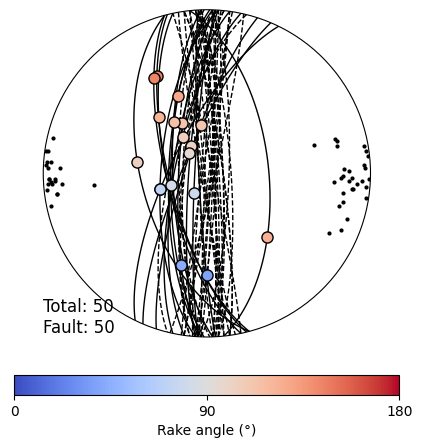

In [ ]:
norm = Normalize(vmin=0, vmax=180)
cmap = plt.get_cmap('coolwarm') # nice color ramp: coolwarm, twilight_shifted
sm = ScalarMappable(norm=norm, cmap=cmap)
colors = sm.to_rgba(rake)
typeToPlot = filtered_df.iloc[:, 1].tolist()

fig, ax = mpl.subplots(figsize=(5,5))

# LINESTYLE for KINEMATIC
# it's possible to colour great circle depending on rake: color=colors[i]
for i in range(num):
  if kinematic[i] == 1: # NORMAL FAULTS
    ax.plane(strike[i], dip[i], color='k', linewidth=1, linestyle='-')
  elif kinematic[i] == 2: # REVERSE FAULTS
    ax.plane(strike[i], dip[i], color='k', linewidth=2, linestyle='')
  elif kinematic[i] == 0: # UNDETERMINED FAULTS
    ax.plane(strike[i], dip[i], color='k', linewidth=1, linestyle='--')
  else:
    ax.plane(strike[i], dip[i], color='k', linewidth=1, linestyle='--')

# LINESTYLE for TYPE - active only if more than one type is selected
'''if filtered_df['Type'].nunique() > 1:
  for i in range(num):
    if typeToPlot[i] == 'Fault':
      ax.plane(strike[i], dip[i], color='k', linewidth=1, linestyle='--')
    if typeToPlot[i] == 'Joint':
      ax.plane(strike[i], dip[i], color='k', linewidth=1, linestyle='-')
    if typeToPlot[i] == 'Vein':
      ax.plane(strike[i], dip[i], color='k', linewidth=1, linestyle=':')'''

# PLOTTING POLES
ax.pole(strike, dip, color='black', marker='o', markersize=2)

# PLOTTING RAKES
if 'Fault' in type and pd.notna(rake).any():
  for i in range(num):
    if pd.notna(rake[i]):
      ax.rake(strike[i], dip[i], rake[i], color=colors[i], marker='o', markersize=8, markeredgewidth=1, markeredgecolor='black')
  cbar = fig.colorbar(sm, ax=ax, orientation='horizontal', fraction=0.05, pad=0.1)
  cbar.set_label('Rake angle (°)')
  cbar.set_ticks([0, 90, 180])
  cbar.set_ticklabels(['0', '90', '180'])

ax.set_azimuth_ticks([])

type_counts = filtered_df['Type'].value_counts()
count_text = ''
for t, count in type_counts.items():
    count_text += f'{t}: {count}\n'
count_text = count_text.strip()

ax.text(0, 0, f'Total: {num}\n{count_text}', fontsize=12, ha='left', va='bottom', transform=ax.transAxes)

#plt.savefig('stereonet', format="svg",dpi=300)
plt.show()

# Plot fault and striae stereonets

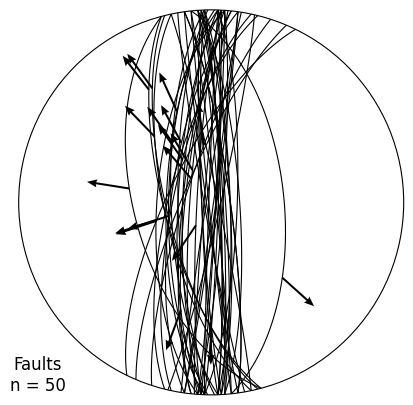

In [ ]:
if 'Fault' in type and pd.notna(rake).any():
  fig, ax = mpl.subplots(figsize=(5,5))
  ax.plane(strike, dip, color='black', linewidth=0.8)

  x, y = mpl.rake(strike, dip, rake)
  mag = np.hypot(x, y)

  u = np.zeros(num)
  v = np.zeros(num)
  for i in range(num):
    if kinematic[i] == 1:
      u[i] = x[i] / mag[i]
      v[i] = y[i] / mag[i]
    elif kinematic[i] == 2:
      u[i] = - x[i] / mag[i]
      v[i] = - y[i] / mag[i]
  arrows = ax.quiver(x, y, u, v, width=2, headwidth=4, units='dots')

  ax.set_azimuth_ticks([])

  type_display_text = ', '.join(type) if isinstance(type, list) else str(type)
  ax.text(0.05, 0.05, f'{type_display_text}s\nn = {num}', fontsize=12, ha='center', va='center', transform=ax.transAxes)

  plt.savefig('stereonet_fault_striae.svg', format="svg", dpi=300)
  plt.show()

# Contour plot
#### Contour method: default (modified Kamb), Kamb, exponential Kamb, linear Kamb, Schmidt

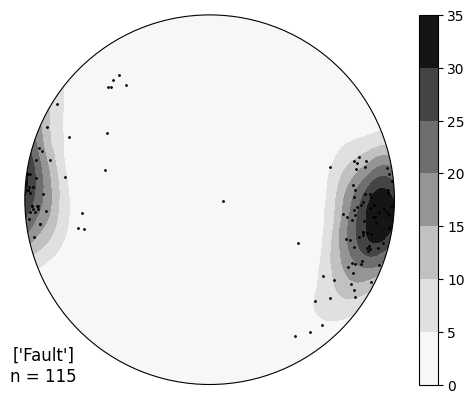

In [ ]:
fig, ax = mpl.subplots()
color = 'Greys'

c = ax.density_contourf(strike,dip, measurement='poles', method='linear_kamb', cmap = color)
#ax.density_contourf(plunge, trend, measurement='lines')

ax.pole(strike, dip, color='black', marker='o', markersize=1)
#ax.line(plunge, trend, color='black', markersize=1)

fig.colorbar(c)
ax.set_azimuth_ticks([])

ax.text(0.05, 0.05, f'{type}\nn = {num}', fontsize=12, ha='center', va='center', transform=ax.transAxes)

plt.show()

# Rose diagram
#### Adjust rose_type depending on the features you want to analyse

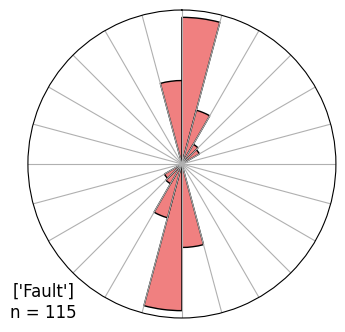

In [ ]:
fig = plt.figure(figsize=(4,4))
ax = fig.add_subplot(projection='polar')
ax.set_theta_zero_location('N')
ax.set_theta_direction(-1)
ax.set_theta_offset(np.pi/2)

bin_edges = np.arange(0, 361, 15)
rose_type = strike # or trend

if type == 'Paleocurrent':
  num_data, bin_edges = np.histogram(rose_type, bin_edges)
  half = num_data[:len(num_data) // 2]
  bin_centers = np.deg2rad((bin_edges[:-1] + bin_edges[1:]) / 2)
  ax.bar(bin_centers[:len(half)], half, width=np.deg2rad(15), bottom=0.0,
       color='lightcoral', edgecolor='k')
else:
  num_data, bin_edges = np.histogram(rose_type, bin_edges)
  num_data[0] += num_data[-1]
  half = num_data[0:12] + num_data[12:24]
  two_halves = np.concatenate([half, half])
  bin_centers = np.deg2rad((bin_edges[:-1] + bin_edges[1:]) / 2)
  ax.bar(bin_centers, two_halves, width=np.deg2rad(15), bottom=0.0,
       color='lightcoral', edgecolor='k')

ax.set_rticks([])
ax.set_thetagrids(np.arange(0,360,15), labels=[])
ax.grid(True)

ax.text(0.05, 0.05, f'{type}\nn = {num}', fontsize=12, ha='center', va='center', transform=ax.transAxes)

plt.show()

# Guassian polymodal fit
#### Analyse subgroups of data into distinct populations described by gaussian distributions. A Bayesian information criterion is use to set the right number of components. Histograms of data and gaussian curves are plotted together, parameters of populations are shown in the table
#### It's preferable to use faults with the same kinematic for a clearer interpretation of data

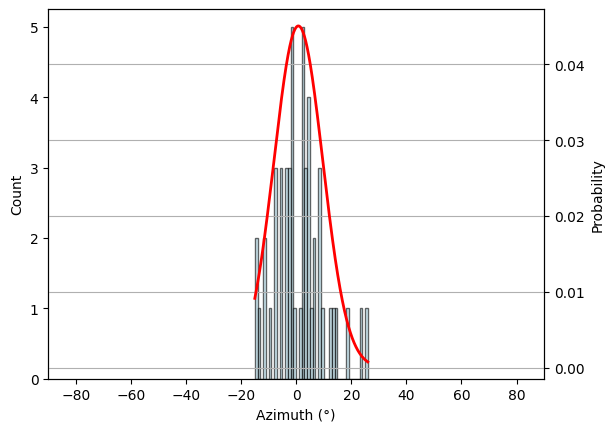

,Parameter,Value
0,Optimal Components,1.000000
1,Mean_1,0.800000
2,StdDev_1,8.852118
3,MixingProp_1,1.000000


In [ ]:
# CHOOSE HERE WHAT YOU WANT TO FIT
fit_type = strike
data_NaN = pd.DataFrame(fit_type)
data_fit = data_NaN.dropna().to_numpy()

if fit_type is strike:
  for i in range(len(data_fit)):
    if data_fit[i] > 90 and data_fit[i] <= 270:
      data_fit[i] = data_fit[i] - 180
    elif data_fit[i] > 270 and data_fit[i] <= 360:
      data_fit[i] = data_fit[i] - 360
    else:
      data_fit[i] = data_fit[i]

maxComponents = 3
BIC = np.zeros(maxComponents)
GMModels = [None] * maxComponents

for k in range(1, maxComponents + 1):
  gm = GaussianMixture(n_components=k, max_iter=500, random_state=42)
  gm.fit(data_fit.reshape(-1, 1))
  GMModels[k - 1] = gm
  BIC[k - 1] = gm.bic(data_fit.reshape(-1, 1))

optimalComponents = np.argmin(BIC) + 1
optimalGM = GMModels[optimalComponents - 1]

fig, ax1 = plt.subplots()

ax1.hist(data_fit, bins=int(np.ptp(data_fit)), density=False, color='lightblue', edgecolor='black', alpha=0.6)
ax1.set_ylabel('Count')

x = np.linspace(min(data_fit), max(data_fit), 1000)
y = np.exp(optimalGM.score_samples(x.reshape(-1, 1)))
ax2 = ax1.twinx()
ax2.plot(x, y, color='red', linewidth=2)
ax2.set_ylabel('Probability')

if fit_type is rake:
  ax1.set_xlim([0, 180])
  ax1.set_xlabel('Rake (°)')
elif fit_type is strike or fit_type is trend:
  ax1.set_xlim([-90, 90])
  ax1.set_xlabel('Azimuth (°)')
elif fit_type is dip or fit_type is plunge:
  ax1.set_xlim([0, 90])
  ax1.set_xlabel('Dip (°)')
plt.grid(True)

# plt.savefig(filename, format="svg",dpi=300)
plt.show()

params = {'Optimal Components': optimalComponents,'Means': optimalGM.means_.flatten(),
    'Std Devs': np.sqrt(optimalGM.covariances_.flatten()),'Mixing Proportions': optimalGM.weights_.flatten()}
params_df = pd.DataFrame({
    'Parameter': ['Optimal Components'] + [f'Mean_{i+1}' for i in range(len(params['Means']))] +
                 [f'StdDev_{i+1}' for i in range(len(params['Std Devs']))] +
                 [f'MixingProp_{i+1}' for i in range(len(params['Mixing Proportions']))],
    'Value': [params['Optimal Components']] + list(params['Means']) +
             list(params['Std Devs']) + list(params['Mixing Proportions'])})
display(params_df)